# Libraries are imported in this cell.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# setting theme for charts
sns.set_style('whitegrid')

#Loading all the raw datasets

In [ ]:
players_info = pd.read_csv('/content/afl_players_info_raw.csv')
seasonal_stats = pd.read_csv('/content/afl_players_seasonal_stats_raw.csv')
round_stats = pd.read_csv('/content/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv')

/tmp/ipykernel_861/1976037802.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  seasonal_stats = pd.read_csv('/content/afl_players_seasonal_stats_raw.csv')


#Cleaning the dataset Players Info

In [ ]:
players_info.head()

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


In [ ]:
players_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   2848 non-null   int64 
 1   player_name          2848 non-null   object
 2   player_full_name     2848 non-null   object
 3   first_name           2848 non-null   object
 4   last_name            2848 non-null   object
 5   born_date            2848 non-null   object
 6   debut_date           2848 non-null   object
 7   debut_age            2848 non-null   int64 
 8   last_date            2848 non-null   object
 9   last_age             2848 non-null   int64 
 10  height               2848 non-null   int64 
 11  weight               2848 non-null   int64 
 12  profile_pic          637 non-null    object
 13  player_link          2848 non-null   object
 14  player_common_names  75 non-null     object
 15  player_teams         2754 non-null   object
dtypes: int

In [ ]:
#parsing string born date and debut date and last date to datetime objects
date_cols = ['born_date','debut_date','last_date']
for col in date_cols:
  players_info[col] = pd.to_datetime(players_info[col])

In [ ]:
#checking again the data types
players_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2848 entries, 0 to 2847
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2848 non-null   int64         
 1   player_name          2848 non-null   object        
 2   player_full_name     2848 non-null   object        
 3   first_name           2848 non-null   object        
 4   last_name            2848 non-null   object        
 5   born_date            2848 non-null   datetime64[ns]
 6   debut_date           2848 non-null   datetime64[ns]
 7   debut_age            2848 non-null   int64         
 8   last_date            2848 non-null   datetime64[ns]
 9   last_age             2848 non-null   int64         
 10  height               2848 non-null   int64         
 11  weight               2848 non-null   int64         
 12  profile_pic          637 non-null    object        
 13  player_link          2848 non-nul

In [ ]:
players_info.describe()

,id,born_date,debut_date,debut_age,last_date,last_age,height,weight
count,2848.000000,2848,2848,2848.000000,2848,2848.000000,2848.000000,2848.000000
mean,44858.623947,1989-05-09 19:48:12.134831360,2009-06-11 22:25:57.303371008,19.595857,2015-08-05 23:31:10.786516736,25.765449,187.344803,86.012289
min,43260.000000,1963-10-23 00:00:00,1983-03-27 00:00:00,16.000000,1999-03-27 00:00:00,18.000000,163.000000,0.000000
25%,44063.750000,1981-11-18 00:00:00,2001-06-07 18:00:00,18.000000,2008-06-07 18:00:00,22.000000,182.000000,80.000000
50%,44885.500000,1990-02-10 12:00:00,2010-05-12 00:00:00,19.000000,2016-07-30 00:00:00,25.000000,187.000000,85.000000
75%,45662.250000,1997-03-20 00:00:00,2017-07-08 06:00:00,20.000000,2024-08-02 06:00:00,29.000000,192.000000,92.000000
max,46374.000000,2006-12-24 00:00:00,2025-08-22 00:00:00,29.000000,2026-03-07 00:00:00,40.000000,211.000000,118.000000
std,912.449281,NaN,NaN,1.824956,NaN,4.339853,7.318328,8.923524


In [ ]:
players_info.shape

(2848, 16)

In [ ]:
#checking the duplicates
players_info.duplicated().sum()

np.int64(5)

In [ ]:
#droping the duplicates
players_info.drop_duplicates(inplace=True)

In [ ]:
players_info.isnull().sum()

,0
id,0
player_name,0
player_full_name,0
first_name,0
last_name,0
born_date,0
debut_date,0
debut_age,0
last_date,0
last_age,0


In [ ]:
# Drop columns with excessive missing values
players_info = players_info.drop(columns=['profile_pic', 'player_common_names'])

In [ ]:
# Handle missing values in player_teams by filling with 'Unknown'
players_info['player_teams'] = players_info['player_teams'].fillna('Unknown')

In [ ]:
players_info.isnull().sum()

,0
id,0
player_name,0
player_full_name,0
first_name,0
last_name,0
born_date,0
debut_date,0
debut_age,0
last_date,0
last_age,0


In [ ]:
from google.colab import files

# Save the cleaned DataFrame to a CSV file
players_info.to_csv('players_info.csv', index=False)

# Trigger the download to the local machine
files.download('players_info.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Now Cleaning the Seasonal Stat dataset and fixing previous mistakes

In [ ]:
seasonal_stats.head(3)

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0


In [ ]:
seasonal_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25491 entries, 0 to 25490
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25491 non-null  object 
 1   year                         25491 non-null  int64  
 2   team                         25491 non-null  object 
 3   is_finals                    25491 non-null  bool   
 4   games_played                 25491 non-null  int64  
 5   kicks                        25439 non-null  float64
 6   marks                        25306 non-null  float64
 7   handballs                    25378 non-null  float64
 8   disposals                    25467 non-null  float64
 9   goals                        22954 non-null  float64
 10  behinds                      22802 non-null  float64
 11  hit_outs                     19785 non-null  float64
 12  tackles                      24980 non-null  float64
 13  rebound_50s     

In [ ]:
# Remove 'ID_' prefix if it exists and convert to integer
seasonal_stats['player_id'] = seasonal_stats['player_id'].astype(str).str.replace('ID_', '')
seasonal_stats['player_id'] = pd.to_numeric(seasonal_stats['player_id'], errors='coerce').astype(int)

In [ ]:
#check id is converted to int
seasonal_stats['player_id'].dtype

dtype('int64')

In [ ]:
#checking duplicates
seasonal_stats.duplicated().sum()

np.int64(10)

In [ ]:
#droping the duplicates
seasonal_stats.drop_duplicates(inplace=True)

In [ ]:
#checking null values
seasonal_stats.isnull().sum()

,0
player_id,0
year,0
team,0
is_finals,0
games_played,0
kicks,52
marks,185
handballs,113
disposals,24
goals,2537


fixing previous mistake of not droping 10 columns and also not filling values with median or mean as it effects the data
#As you said in suggestion imputing missing Values with 0

In [ ]:
#impute missing numeric sports metrics with 0
seasonal_stats_num_cols = seasonal_stats.select_dtypes(include=np.number).columns
seasonal_stats[seasonal_stats_num_cols] = seasonal_stats[seasonal_stats_num_cols].fillna(0)

In [ ]:
#now again checking for null values
seasonal_stats.isnull().sum()

,0
player_id,0
year,0
team,0
is_finals,0
games_played,0
kicks,0
marks,0
handballs,0
disposals,0
goals,0


In [ ]:
seasonal_stats.shape

(25481, 54)

In [ ]:
#checking for teams as many teams have same name but due to capital letter they are considered different
print("Unique Teams:")
print(sorted(seasonal_stats['team'].unique()))

Unique Teams:
[' ADELAIDE CROWS ', ' Adelaide Crows ', ' BRISBANE LIONS ', ' Brisbane Lions ', ' CARLTON BLUES ', ' COLLINGWOOD MAGPIES ', ' Carlton Blues ', ' Collingwood Magpies ', ' ESSENDON BOMBERS ', ' Essendon Bombers ', ' FREMANTLE DOCKERS ', ' Fitzroy Lions ', ' Fremantle Dockers ', ' GOLD COAST SUNS ', ' GREATER WESTERN SYDNEY GIANTS ', ' Geelong Cats ', ' Gold Coast Suns ', ' Greater Western Sydney Giants ', ' HAWTHORN HAWKS ', ' Hawthorn Hawks ', ' Melbourne Demons ', ' NORTH MELBOURNE KANGAROOS ', ' North Melbourne Kangaroos ', ' PORT ADELAIDE POWER ', ' Port Adelaide Power ', ' RICHMOND TIGERS ', ' Richmond Tigers ', ' ST KILDA SAINTS ', ' SYDNEY SWANS ', ' St Kilda Saints ', ' Sydney Swans ', ' WEST COAST EAGLES ', ' WESTERN BULLDOGS ', ' West Coast Eagles ', ' Western Bulldogs ', ' adelaide crows ', ' brisbane bears ', ' brisbane lions ', ' carlton blues ', ' collingwood magpies ', ' essendon bombers ', ' fremantle dockers ', ' geelong cats ', ' gold coast suns ', ' grea

In [ ]:
#now fixing this by lowering all
# Convert team names to lowercase and strip whitespace
seasonal_stats['team'] = seasonal_stats['team'].str.lower().str.strip()

# Again Verify the unique list of team names
print("Cleaned Unique Teams:")
print(sorted(seasonal_stats['team'].unique()))

Cleaned Unique Teams:
['adelaide crows', 'brisbane bears', 'brisbane lions', 'carlton blues', 'collingwood magpies', 'essendon bombers', 'fitzroy lions', 'fremantle dockers', 'geelong cats', 'gold coast suns', 'greater western sydney giants', 'hawthorn hawks', 'melbourne demons', 'north melbourne kangaroos', 'port adelaide power', 'richmond tigers', 'st kilda saints', 'sydney swans', 'west coast eagles', 'western bulldogs']


In [ ]:
#now downloading the cleaned file
from google.colab import files

# Save the cleaned DataFrame to a CSV file
seasonal_stats.to_csv('seasonal_stats.csv', index=False)

# Trigger the download to the local machine
files.download('seasonal_stats.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Cleaning the final dataset

In [ ]:
round_stats.head(3)

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48


In [ ]:
round_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  object 
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  object 
 5   round                      274089 non-null  object 
 6   result                     274089 non-null  object 
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    19

In [ ]:
#parsing the match date to datetime
round_stats['match_date'] = pd.to_datetime(round_stats['match_date'])

In [ ]:
#checking the conversion
round_stats['match_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 274089 entries, 0 to 274088
Series name: match_date
Non-Null Count   Dtype         
--------------   -----         
274089 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.1 MB


In [ ]:
#check for duplicates
round_stats.duplicated().sum()

np.int64(10)

In [ ]:
#droping the duplicates
round_stats.drop_duplicates(inplace=True)

In [ ]:
round_stats.shape

(274079, 36)

In [ ]:
#checking null values
round_stats.isnull().sum()

,0
id,0
team,0
year,0
career_game_count,0
opponent,0
round,0
result,0
jersey_num,0
kicks,1299
marks,8048


In [ ]:
#impute missing numeric sports metrics with 0
round_stats_num_cols = round_stats.select_dtypes(include=np.number).columns
round_stats[round_stats_num_cols] = round_stats[round_stats_num_cols].fillna(0)

In [ ]:
#again checking the null
round_stats.isnull().sum()

,0
id,0
team,0
year,0
career_game_count,0
opponent,0
round,0
result,0
jersey_num,0
kicks,0
marks,0


In [ ]:
# Drop the single row where critical columns are null
round_stats.dropna(subset=['opponent', 'round', 'result', 'match_date'], inplace=True)

# Verify that no nulls remain
print("Missing values after dropping the empty row:")
print(round_stats[['opponent', 'round', 'result', 'match_date']].isnull().sum())

Missing values after dropping the empty row:
opponent      0
round         0
result        0
match_date    0
dtype: int64


In [ ]:
#no issue of letter like in previous seasonal stats dataset
print("Unique Teams:")
print(sorted(round_stats['team'].unique()))

Unique Teams:
['Adelaide Crows', 'Brisbane Bears', 'Brisbane Lions', 'Carlton Blues', 'Collingwood Magpies', 'Essendon Bombers', 'Fitzroy Lions', 'Fremantle Dockers', 'Geelong Cats', 'Gold Coast Suns', 'Greater Western Sydney Giants', 'Hawthorn Hawks', 'Melbourne Demons', 'North Melbourne Kangaroos', 'Port Adelaide Power', 'Richmond Tigers', 'St Kilda Saints', 'Sydney Swans', 'West Coast Eagles', 'Western Bulldogs']


In [ ]:
#now downloading the cleaned round stats dataset
from google.colab import files

# Save the cleaned DataFrame to a CSV file
round_stats.to_csv('round_by_round_stats.csv', index=False)

# Trigger the download to the local machine
files.download('round_by_round_stats.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Dataset Merging Strategy
Now that our data is clean and standardized, we need to create consolidated views to solve the business tasks. I will not merge all three datasets into a single massive table, as that would cause significant data duplication (e.g., a player's seasonal totals would repeat for every single round they played).

Instead, we need two distinct analytical DataFrames. Here is the breakdown of which datasets to merge, how to merge them, and why.

#1.The "Season-Level" Merge (season + info)
Datasets: seasonal_stats.csv (Left) + players_info.csv (Right)

Merge Key: player_id (from Season) matched to id (from Info).

Merge Type: LEFT JOIN (how='left').

#Why this merge?
This DataFrame is essential for the Top 10 MVPs and Team Performance Analysis tasks. The seasonal stats contain all the aggregated data we need (totals and averages), but we need the player demographics (specifically player_name) from the info dataset so our final charts and recommendations display actual names instead of meaningless ID numbers. Using a left join ensures we do not lose any player's statistical record even if their demographic profile is missing from the info table.

#2.The "Round-Level" Merge (rounds + info)
Datasets: players_round_by_round_stats_raw.csv (Left) + players_info.csv (Right)

Merge Key: player_id (from Rounds) matched to id (from Info).

Merge Type: LEFT JOIN (how='left').

#Why this merge?
This DataFrame is critical for calculating Consistency and Performance Trends. Consistency is measured by looking at the variance (or standard deviation) of a player's fantasy points across individual matches. Trends require splitting a season into halves (e.g., Rounds 1-11 vs. Rounds 12+). The info dataset is joined here to map the player_name directly to their per-game logs.

In [ ]:
#1 Seasonal level merge for MVP and team performance
season_df=pd.merge(seasonal_stats, players_info, left_on='player_id', right_on='id',how='left')

In [ ]:
#droping the redundant id col because there will be two id columns if i donot drop it
season_df=season_df.drop(columns=['id'])

In [ ]:
from google.colab import files

# Save the merged seasonal dataset to a CSV file
season_df.to_csv('season_level_merged.csv', index=False)

# Trigger the download
files.download('season_level_merged.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#2 Round Level Merge to calculate Consistency and Performance Trends
round_df=pd.merge(round_stats, players_info, left_on='player_id', right_on='id',how='left')

In [ ]:
from google.colab import files

# Drop redundant ID column (renamed during merge) and rename id_x back to id
if 'id_y' in round_df.columns:
    round_df = round_df.drop(columns=['id_y'])
if 'id_x' in round_df.columns:
    round_df = round_df.rename(columns={'id_x': 'id'})

# Save to CSV
round_df.to_csv('round_level_merged.csv', index=False)

# Trigger the download
files.download('round_level_merged.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Task 1: Identify the Top 10 Most Valuable Players
To find the most valuable players, we need to design a custom Performance Index (PI). A great PI in Australian Rules Football (AFL) shouldn't just look at who scores the most points, it needs to measure a player's overall impact on the field, including possession, defense, and playmaking.

In [ ]:
# ## Task 1: Identify the Top 10 Most Valuable Players
# To find the most reliable recruits for the upcoming season, we calculate a custom Performance Index (PI)
# based on a player's historical average across ALL available seasons.
# This prevents bias from single-season anomalies.

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate stats across all seasons for each player
# We take the mean of their per-season averages to get their overall career averages
career_stats = season_df.groupby(['player_id', 'player_name']).agg(
    total_games=('games_played', 'sum'),
    career_avg_disposals=('avg_disposals', 'mean'),
    career_avg_goals=('avg_goals', 'mean'),
    career_avg_tackles=('avg_tackles', 'mean'),
    career_avg_clearances=('avg_clearances', 'mean'),
    career_avg_inside_50s=('avg_inside_50s', 'mean')
).reset_index()
#Filter out the players which have less than 50 games
career_stats = career_stats[career_stats['total_games'] >= 50]


#I have filter out players with less than 50 games because players with only 2 to 3 games were also appearing and it was screwing the average

In [ ]:
# 3. Calculate the Performance Index (PI)
# The formula weights 5 different statistics based on their relative difficulty and impact.
career_stats['Performance_Index'] = (
    (career_stats['career_avg_disposals'] * 0.2) +
    (career_stats['career_avg_goals'] * 5.0) +
    (career_stats['career_avg_tackles'] * 1.5) +
    (career_stats['career_avg_clearances'] * 2.0) +
    (career_stats['career_avg_inside_50s'] * 1.0)
)

In [ ]:
# 4. Rank the players and showing them in table form first
career_stats.sort_values(by='Performance_Index', ascending=False).head(10)

,player_id,player_name,total_games,career_avg_disposals,career_avg_goals,career_avg_tackles,career_avg_clearances,career_avg_inside_50s,Performance_Index
1427,44895,Caleb Serong,127,27.637500,0.500000,5.062500,7.162500,5.150000,35.096250
1200,44630,Clayton Oliver,205,27.835714,0.471429,6.300000,6.585714,4.350000,34.895714
1372,44829,Matt Rowell,110,21.314286,0.742857,6.957143,6.000000,4.000000,34.412857
839,44215,Josh Kennedy,290,25.712500,1.091667,5.150000,6.058333,3.625000,34.067500
137,43414,Marcus Bontempelli,258,23.173684,0.963158,5.273684,5.226316,4.926316,32.740000
338,43642,Patrick Cripps,230,24.492857,0.700000,5.192857,6.457143,3.414286,32.516429
1290,44733,Matt Priddis,240,25.872222,0.311111,6.777778,6.161111,3.244444,32.463333
1827,45359,Simon Black,322,23.021739,1.100000,4.317391,5.334783,4.308696,31.558696
2050,45582,Lenny Hayes,297,22.695238,1.114286,5.595238,4.457143,3.776190,31.193810
366,43674,Patrick Dangerfield,360,22.716667,1.030000,3.650000,5.203333,4.700000,30.275000


/tmp/ipykernel_861/2142831274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Performance_Index', y='player_name', data=career_stats.sort_values(by='Performance_Index', ascending=False).head(10), palette='viridis')


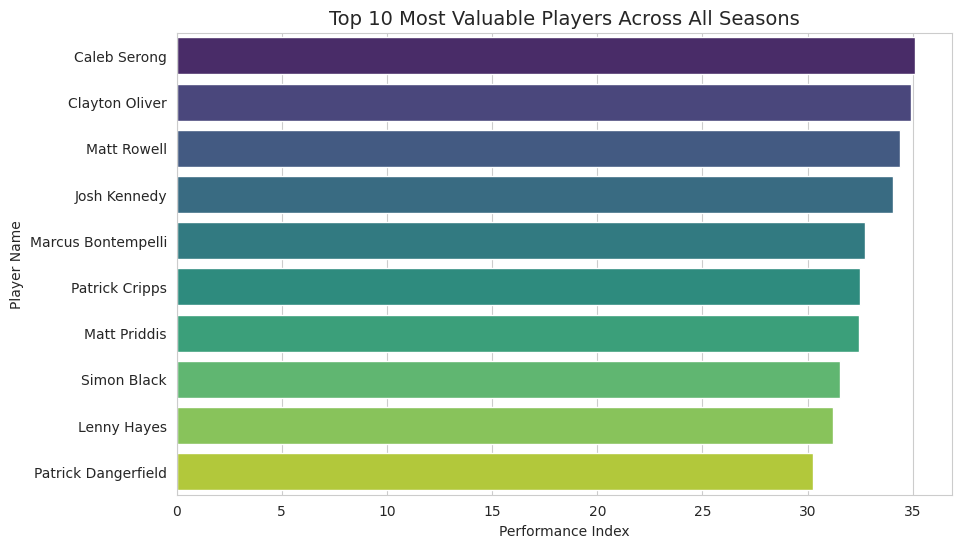

In [ ]:
#Visualizing the top 10 MVPs
plt.figure(figsize=(10, 6))
sns.barplot(x='Performance_Index', y='player_name', data=career_stats.sort_values(by='Performance_Index', ascending=False).head(10), palette='viridis')
plt.title('Top 10 Most Valuable Players Across All Seasons', fontsize=14)
plt.xlabel('Performance Index')
plt.ylabel('Player Name')
plt.show()

#✅Explanation here

#Explanation of Performance Index Usage (Why I used these Statistics)
I have used this PI for MVPs, because relying solely on standard points or goals scored would heavily favour forwards and ignores midfielders and defenders.<br>
1.I used Average Disposals because they tell us how often a player gets
their hand on the ball.<br>
2.Secondly, I used Goals which is one of the most important metric and it shows player ability to put points on scoreboard.<br>
3.Average Tackles represent defensive work rate of a player.<br>
4.Average Clearances tell us players ability to win the ball at stoppages.<br>
5.Average Inside 50 tells us how often a player creates scoring chance for his team.

#▶How I ranked players
1. Aggregation (Creating the Baseline)
Instead of looking at isolated games or a single season, every player's statistics were grouped and averaged across their entire available career in the dataset. This creates a highly reliable "historical average" that smooths out injuries, bad seasons, or lucky streaks.

2. The Qualification Filter
Before any ranking occurred, a strict threshold filter was applied (total_games >= 50). This prevents statistical anomalies. Without this filter, a rookie who played a single game, scored 4 goals, and then got injured would mathematically register as the greatest player in the league. Filtering ensures only established, proven talent is ranked.

3. Calculating the Performance Index
Every qualified player's historical averages were passed through the weighted Performance Index formula. The weights mathematically penalize high-frequency/low-impact actions (like standard disposals) while heavily rewarding low-frequency/high-impact actions (like goals and clearances).

#Task 2 Finding the most Consistent Players
To find the most consistent players, we need to analyze performance on a match-by-match basis. Measuring consistency means looking for players who reliably deliver similar output every single week, without wild fluctuations

In [ ]:
# 1. Filter for the most recent season to evaluate current consistency
latest_year_rounds = round_df['year'].max()
recent_rounds = round_df[round_df['year'] == latest_year_rounds].copy()

In [ ]:
# 2. Group by player and calculate match counts, mean, and standard deviation of Fantasy Points
consistency_df = recent_rounds.groupby(['player_id', 'player_name']).agg(
    Games_Played=('round', 'count'),
    Mean_Fantasy=('fantasy_points', 'mean'),
    Std_Fantasy=('fantasy_points', 'std')
).reset_index()

In [ ]:
# 3. Apply a minimum game threshold
# A player must have played at least 15 games in the season.
# Without this, a player who played 2 games and scored the same points would incorrectly be flagged as "perfectly consistent".
consistency_df = consistency_df[consistency_df['Games_Played'] >= 15]

In [ ]:
# 4. Calculate the Coefficient of Variation (CV)
# CV = Standard Deviation / Mean (Lower CV = Higher Consistency)
consistency_df['CV'] = consistency_df['Std_Fantasy'] / consistency_df['Mean_Fantasy']

In [ ]:
# 5. Identify the Top 10 Most Consistent Players (Lowest CV)
most_consistent = consistency_df.sort_values('CV', ascending=True).head(10)
most_consistent.head(10)

,player_id,player_name,Games_Played,Mean_Fantasy,Std_Fantasy,CV
262,44249,Rory Laird,22,93.227273,14.595928,0.156563
380,44681,Christian Petracca,23,90.391304,14.584360,0.161347
19,43312,Tom Atkins,26,88.269231,14.578224,0.165156
152,43795,Tim English,23,110.739130,18.793658,0.169711
190,43936,Tom Green,23,97.521739,16.599205,0.170210
187,43920,Jack Graham,18,82.666667,14.266373,0.172577
78,43540,Adam Cerra,19,95.052632,16.547822,0.174091
409,44778,Ed Richards,23,96.652174,16.835052,0.174182
472,45061,Tim Taranto,21,93.857143,16.544745,0.176276
523,45271,Jarrod Witts,24,92.125000,16.392767,0.177940


/tmp/ipykernel_861/3305593887.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_10_rounds_data, x='player_name', y='fantasy_points', palette='Set2',order=top_10_consistent_names)


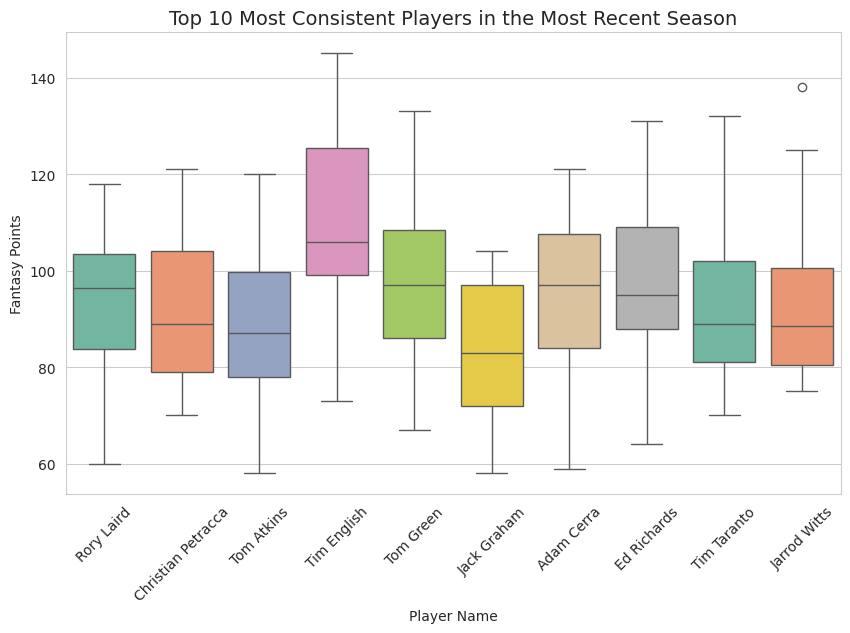

In [ ]:
# 6. Visualization: Box Plot of the Top 10 Consistent Players
# We use a box plot because it perfectly visualizes statistical spread.
top_10_consistent_names = most_consistent['player_name'].head(10)
top_10_rounds_data = recent_rounds[recent_rounds['player_name'].isin(top_10_consistent_names)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_10_rounds_data, x='player_name', y='fantasy_points', palette='Set2',order=top_10_consistent_names)
plt.title('Top 10 Most Consistent Players in the Most Recent Season', fontsize=14)
plt.xlabel('Player Name')
plt.ylabel('Fantasy Points')
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 8.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


Text(-16.777777777777786, 0.5, 'Player Name')

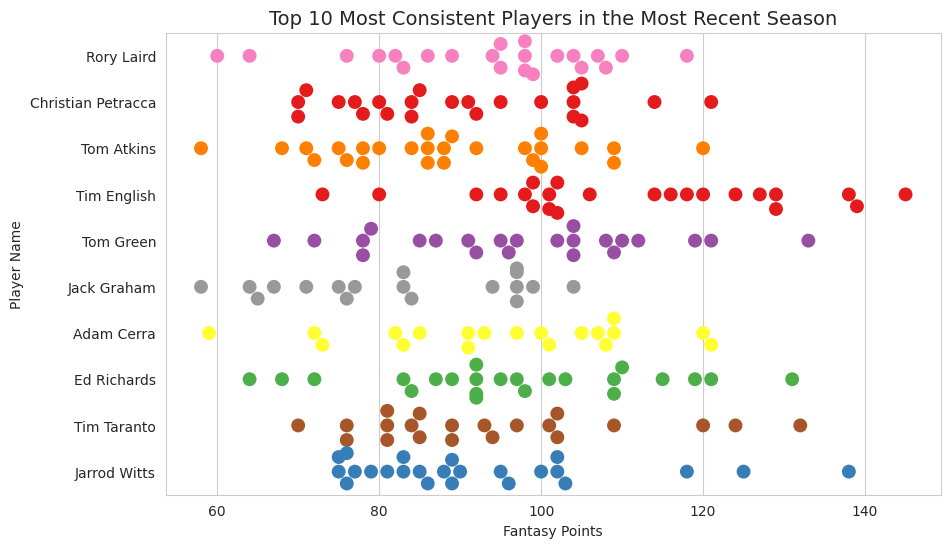

In [ ]:
# Add a swarmplot on top to show the individual match data points
plt.figure(figsize=(10, 6))
sns.swarmplot(data=top_10_rounds_data, x='fantasy_points', y='player_name', size=10,order=top_10_consistent_names,hue='player_name', palette='Set1')
plt.title('Top 10 Most Consistent Players in the Most Recent Season', fontsize=14)
plt.xlabel('Fantasy Points')
plt.ylabel('Player Name')

#✅Explanation of Statistics Used and How I ranked them
The Statistic Used (Coefficient of Variation): Consistency cannot be measured by average score alone. We used Fantasy Points as a holistic measure of a single game's performance. By dividing a player's Standard Deviation by their Mean (average) score, we calculated their CV. A score closer to 0.0 means the player's performance barely fluctuates round-by-round.

The Game Threshold (>= 15 games): Consistency is only valuable if it is tested over time. Filtering out players with fewer than 15 games ensures we are only looking at reliable, season-long starters rather than reserves who only played a couple of matches.

#Task 3: Identify Performance Trends
To identify players who improved and declined, we need to look at how their performance changed as the season progressed. The most effective way to measure this is by splitting the season into two halves (e.g., First Half vs. Second Half) and comparing their average output in each period.

In [ ]:
# 1. Filter for the most recent season
latest_year = round_df['year'].max()
recent_rounds = round_df[round_df['year'] == latest_year].copy()

In [ ]:
# 2. Determine the midpoint of the season
recent_rounds['round_num'] = pd.to_numeric(recent_rounds['round'], errors='coerce')
max_round = recent_rounds['round_num'].max()
midpoint = max_round // 2

In [ ]:
# 3. Tag each match as 'First_Half' or 'Second_Half'
# Use 'round_num' for the comparison instead of the string 'round' column
recent_rounds['Season_Half'] = np.where(recent_rounds['round_num'] <= midpoint, 'First_Half', 'Second_Half')

# 4. Calculate average fantasy points and games played per half for each player
trend_df = recent_rounds.groupby(['player_name', 'Season_Half']).agg(
    Avg_Points=('fantasy_points', 'mean'),
    Games_Played=('round_num', 'count')
).reset_index()

In [ ]:
# 5. Pivot the data so First Half and Second Half are columns side-by-side
trend_pivot = trend_df.pivot(index='player_name', columns='Season_Half', values=['Avg_Points', 'Games_Played'])
trend_pivot.columns = ['{}_{}'.format(col[0], col[1]) for col in trend_pivot.columns]
trend_pivot = trend_pivot.reset_index()

In [ ]:
# 6. Apply a minimum games threshold
# A player must have played at least 5 games in BOTH halves to be evaluated fairly.
trend_pivot = trend_pivot.dropna() # Drop players who only played in one half
trend_pivot = trend_pivot[
    (trend_pivot['Games_Played_First_Half'] >= 5) &
    (trend_pivot['Games_Played_Second_Half'] >= 5)
]

In [ ]:
# 7. Calculate Improvement Margin
# Positive = Improved, Negative = Declined
trend_pivot['Improvement_Margin'] = trend_pivot['Avg_Points_Second_Half'] - trend_pivot['Avg_Points_First_Half']

In [ ]:
# 8. Identify Top 5 Improvers and Top 5 Decliners
improvers = trend_pivot.sort_values('Improvement_Margin', ascending=False).head(5)
decliners = trend_pivot.sort_values('Improvement_Margin', ascending=True).head(5)

In [ ]:
# Combine for visualization
trend_extremes = pd.concat([improvers, decliners]).sort_values('Improvement_Margin', ascending=True)

In [ ]:
#showing players who improved in second half
improvers.head(5)

,player_name,Avg_Points_First_Half,Avg_Points_Second_Half,Games_Played_First_Half,Games_Played_Second_Half,Improvement_Margin
404,Lachlan Cowan,41.833333,79.500000,6.0,8.0,37.666667
155,Colby McKercher,60.909091,94.583333,11.0,12.0,33.674242
323,Jarman Impey,59.600000,88.857143,10.0,11.0,29.257143
384,Kai Lohmann,34.285714,62.454545,7.0,7.0,28.168831
174,Daniel Curtin,50.916667,78.461538,12.0,11.0,27.544872


In [ ]:
#showing 5 players who declined in second half
decliners.head(5)

,player_name,Avg_Points_First_Half,Avg_Points_Second_Half,Games_Played_First_Half,Games_Played_Second_Half,Improvement_Margin
33,Nic Martin,106.727273,77.000000,11.0,5.0,-29.727273
543,Riley Bice,65.454545,37.400000,11.0,5.0,-28.054545
506,Nick Holman,46.900000,19.666667,10.0,6.0,-27.233333
464,Matt Roberts,91.583333,65.000000,12.0,6.0,-26.583333
652,Xavier Lindsay,62.545455,36.571429,11.0,7.0,-25.974026


/tmp/ipykernel_861/3101640182.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trend_extremes, x='Improvement_Margin', y='player_name', palette=colors)


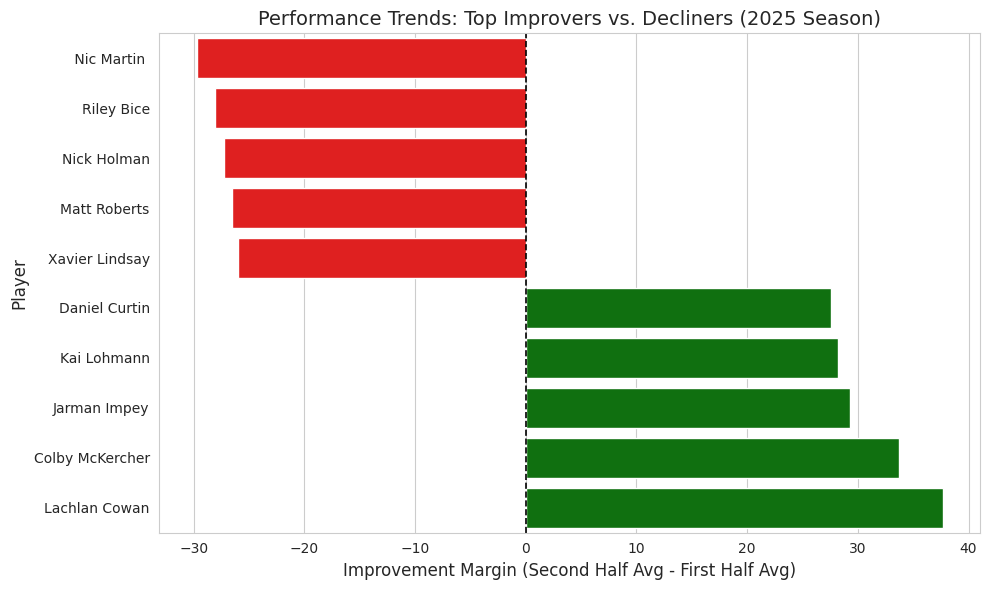

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in trend_extremes['Improvement_Margin']]

sns.barplot(data=trend_extremes, x='Improvement_Margin', y='player_name', palette=colors)

plt.title(f"Performance Trends: Top Improvers vs. Decliners ({latest_year} Season)", fontsize=14)
plt.xlabel("Improvement Margin (Second Half Avg - First Half Avg)", fontsize=12)
plt.ylabel("Player", fontsize=12)

# Add a vertical line at 0 for visual clarity
plt.axvline(0, color='black', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.show()

#✅ Explanation How I measured Improvement
How Improvement Was Measured: Improvement was quantified by dividing the season into two halves based on the maximum number of rounds. A player's average fantasy_points in the First Half (Rounds 1 to midpoint) was subtracted from their average in the Second Half (Rounds post-midpoint).

A positive margin indicates the player surged and improved as the season went on.

A negative margin indicates the player fatigued or their form declined late in the year.

#The Threshold Filter:
To ensure the trends were legitimate and not just statistical noise, players were required to have played a minimum of 5 games in both the first and second halves of the season. This prevents a player who had one lucky game in Round 20 from being labeled the "most improved" player of the year.

#The Metric Used:
Fantasy Points were chosen as the evaluation metric because they capture a holistic view of a player's impact per match, summarizing offensive, defensive, and possession-based contributions into a single readable number.

#Task 4: Team Performance Analysis
To rank the teams, I need a metric that reflects the overall quality and depth of the squad. Relying on a single stat (like total team goals) ignores defensive setups, and using "Total Player Points" unfairly rewards teams that had high injury rates and used more players throughout the season.

In [ ]:
# 1. Filter for the latest season to analyze current team strength
latest_year = season_df['year'].max()
current_season_teams = season_df[season_df['year'] == latest_year].copy()

In [ ]:
# 2. Filter for core players (e.g., played at least 5 games)
# This prevents reserve/fringe players from mathematically dragging down a team's average.
current_season_teams = current_season_teams[current_season_teams['games_played'] >= 5]

In [ ]:
# 3. Calculate Performance Index (PI) for each player (using our established formula for players Now we use same for teams)
current_season_teams['Performance_Index'] = (
    (current_season_teams['avg_disposals'] * 0.2) +
    (current_season_teams['avg_goals'] * 5.0) +
    (current_season_teams['avg_tackles'] * 1.5) +
    (current_season_teams['avg_clearances'] * 2.0) +
    (current_season_teams['avg_inside_50s'] * 1.0)
)

In [ ]:
# 4. Group by team and calculate the Mean Performance Index
team_rankings = current_season_teams.groupby('team').agg(
    Core_Players=('player_id', 'count'),
    Average_Player_PI=('Performance_Index', 'mean'),
    Total_Team_PI=('Performance_Index', 'sum')
).reset_index()

In [ ]:
#5 Rank the teams based on their average player PI
team_rankings = team_rankings.sort_values(by='Average_Player_PI', ascending=False)

In [ ]:
team_rankings.head(3)

,team,Core_Players,Average_Player_PI,Total_Team_PI
6,geelong cats,28,21.003214,588.09
7,gold coast suns,30,20.610333,618.31
9,hawthorn hawks,29,20.336207,589.75


/tmp/ipykernel_861/2706911861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_rankings, x='Average_Player_PI', y='team', palette='magma')


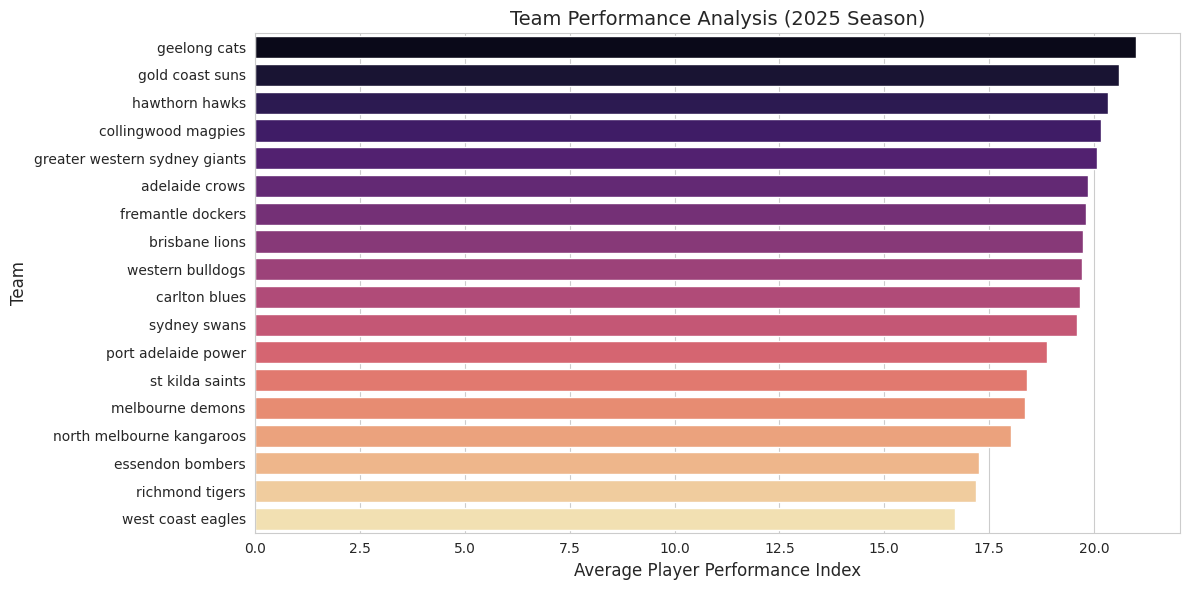

In [ ]:
#Visualization : Bar chart of team rankings
plt.figure(figsize=(12, 6))
sns.barplot(data=team_rankings, x='Average_Player_PI', y='team', palette='magma')
plt.title(f"Team Performance Analysis ({latest_year} Season)", fontsize=14)
plt.xlabel("Average Player Performance Index", fontsize=12)
plt.ylabel("Team", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_861/3497817766.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=current_season_teams, x='Performance_Index',y='team',order=team_order,palette='coolwarm')


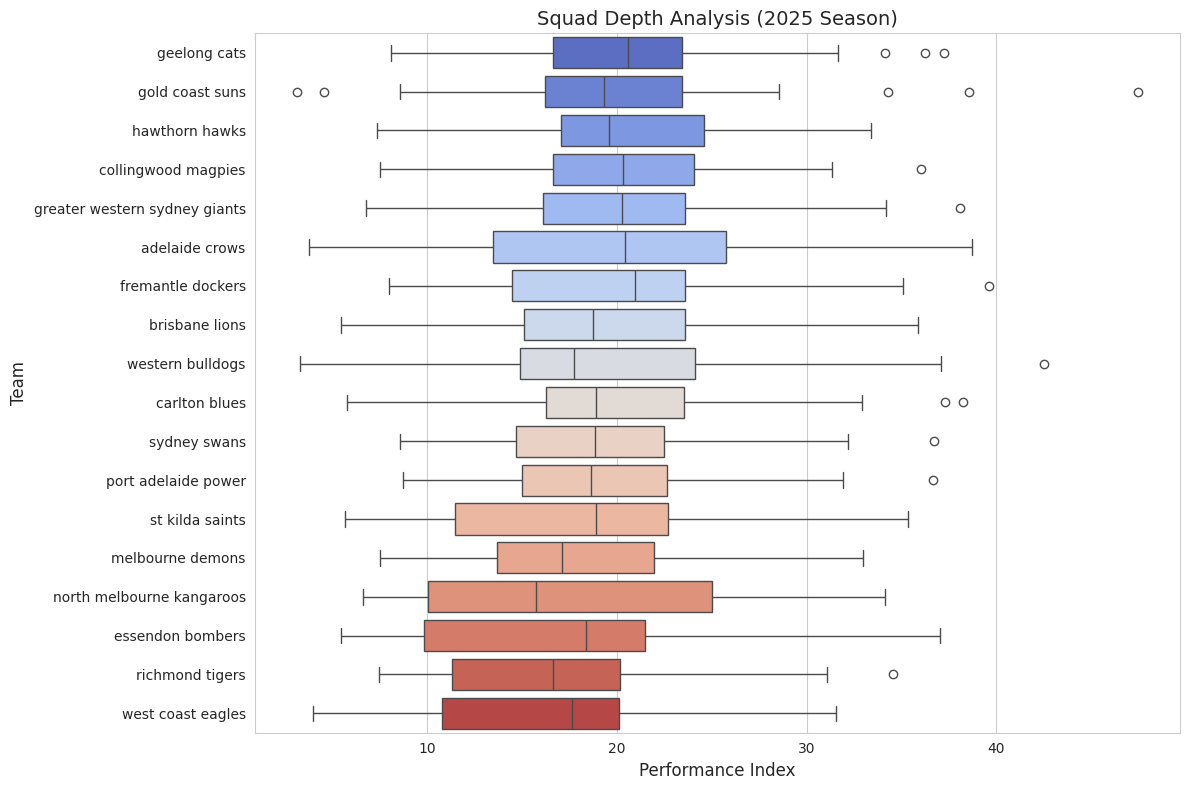

In [ ]:
#  Visualization 2: Box Plot of Squad Depth
# Order the teams based on the previously calculated ranking
team_order = team_rankings['team'].tolist()

plt.figure(figsize=(12, 8))
sns.boxplot(data=current_season_teams, x='Performance_Index',y='team',order=team_order,palette='coolwarm')
plt.title(f"Squad Depth Analysis ({latest_year} Season)", fontsize=14)
plt.xlabel("Performance Index", fontsize=12)
plt.ylabel("Team", fontsize=12)
plt.tight_layout()
plt.show()

#Explanation of Metrics Used
Justification of Metrics Used for RankingTo determine the strongest overall team, the Average Player Performance Index (Mean PI) of the core squad was used. Here is why this specific metric was chosen over alternatives:Why the Performance Index?Instead of ranking teams by raw wins or total goals, we used the custom Performance Index $PI$ established in Task
1. Since $PI$ aggregates offensive, defensive, and possession-based metrics into a single score, ranking teams by this index measures their actual on-field dominance and holistic effort, independent of match outcomes.<br>
2. Why "Average" Instead of "Total"? If we ranked teams by the Total PI of all their players, teams that suffered heavy injuries and had to field 40 different players throughout the season might artificially inflate their total score. By taking the Mean (Average) PI of the roster, we measure the density of talent.
The highest-ranked team is the one where the average player stepping onto the field is statistically superior to the average player of another team.
4. The Core Squad Filter ($\ge 5$ Games):Before calculating the team average, players who participated in fewer than 5 games were filtered out. Reserve players generally have highly volatile or very low stats. Including them would unfairly drag down the team's average. Filtering ensures that the ranking represents the strength of the team's actual starting and rotational lineup.

#Task 5: Feature Engineering
Feature engineering involves creating new, meaningful metrics from existing data to uncover deeper insights.

In [ ]:
# Ensure we are working with a clean copy of the merged data
advanced_stats = season_df.copy()

# 1. Goals Per Game
advanced_stats['Goals_Per_Game'] = np.where(
    advanced_stats['games_played'] > 0,
    advanced_stats['goals'] / advanced_stats['games_played'],
    0
)

In [ ]:
# 2. Fantasy Points Per Game
advanced_stats['Fantasy_Per_Game'] = np.where(
    advanced_stats['games_played'] > 0,
    advanced_stats['total_fantasy_points'] / advanced_stats['games_played'],
    0
)

In [ ]:
# 3. Contested Possession Rate (What percentage of their disposals are hard-won?)
advanced_stats['Contested_Possession_Rate'] = np.where(
    advanced_stats['disposals'] > 0,
    advanced_stats['contested_possessions'] / advanced_stats['disposals'],
    0
)

In [ ]:
# 4. Scoring Accuracy (Goals vs. Behinds)
total_shots = advanced_stats['goals'] + advanced_stats['behinds']
advanced_stats['Scoring_Accuracy'] = np.where(
    total_shots > 0,
    advanced_stats['goals'] / total_shots,
    0
)

In [ ]:
# 5. Defensive Workrate (Combined defensive actions per game)
defensive_actions = advanced_stats['tackles'] + advanced_stats['one_percenters'] + advanced_stats['rebound_50s']
advanced_stats['Defensive_Workrate'] = np.where(
    advanced_stats['games_played'] > 0,
    defensive_actions / advanced_stats['games_played'],
    0
)

In [ ]:
# Preview the new features
new_features = ['player_name', 'Goals_Per_Game', 'Fantasy_Per_Game', 'Contested_Possession_Rate', 'Scoring_Accuracy', 'Defensive_Workrate']
print("--- Newly Engineered Features Snapshot ---")
display(advanced_stats[new_features].head(10))

--- Newly Engineered Features Snapshot ---


,player_name,Goals_Per_Game,Fantasy_Per_Game,Contested_Possession_Rate,Scoring_Accuracy,Defensive_Workrate
0,Ryan Abbott,1.000000,92.666667,0.526316,0.600000,11.000000
1,Ryan Abbott,0.000000,61.000000,0.400000,0.000000,10.000000
2,Ryan Abbott,1.000000,74.000000,0.545455,1.000000,8.000000
3,Ryan Abbott,1.000000,22.000000,0.000000,1.000000,0.000000
4,Gary Ablett,0.833333,36.916667,0.680000,0.769231,3.166667
5,Gary Ablett,1.181818,68.090909,0.565749,0.565217,6.045455
6,Gary Ablett,1.722222,68.388889,0.605578,0.563636,6.333333
7,Gary Ablett,1.333333,75.666667,0.440000,0.800000,7.000000
8,Gary Ablett,1.181818,76.045455,0.475490,0.520000,5.727273
9,Gary Ablett,1.500000,75.000000,0.518519,0.600000,7.000000


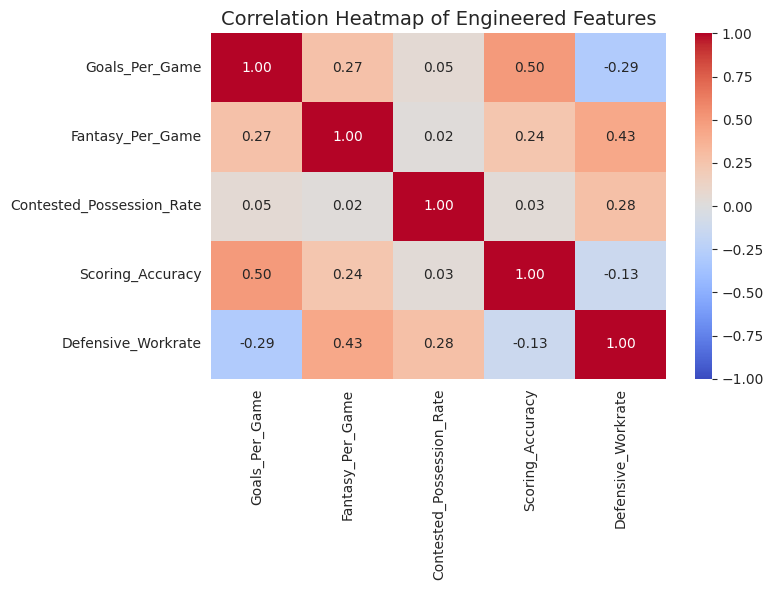

In [ ]:
# Visualization: Correlation Heatmap of New Features
plt.figure(figsize=(8, 6))
corr_matrix = advanced_stats[['Goals_Per_Game', 'Fantasy_Per_Game', 'Contested_Possession_Rate', 'Scoring_Accuracy', 'Defensive_Workrate']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap of Engineered Features", fontsize=14)
plt.tight_layout()
plt.show()

#Explanation
1. Goals Per Game

Why it is useful: Relying on total goals is heavily biased toward players who simply played more matches in a season. Normalizing this to a per-game average reveals the true lethal capability of a forward. A player scoring 2.5 goals per game over 12 games is arguably a better offensive threat than a player who scored 1.2 goals per game over 24 games.

2. Fantasy Points Per Game

Fantasy points summarize a vast array of actions (kicks, marks, tackles, goals) into one neat value. Averaging this per game gives us a standard, holistic "Impact Floor" for a player. It tells a recruiter exactly how much baseline value the player generates every time they step onto the field.

3. Contested Possession Rate

A high raw disposal count can sometimes be a vanity metric if the player is just receiving uncontested, easy handballs on the outside. By dividing contested_possessions by total disposals, we measure a player's "toughness." A high rate indicates an inside-midfielder who does the gritty, difficult work of extracting the ball from opposing players.

4. Scoring Accuracy

If two players both average 2 goals per game, they look identical on paper. However, if Player A kicks 2 goals and 0 behinds (100% accuracy), while Player B kicks 2 goals and 4 behinds (33% accuracy), Player B is wasting possessions and hurting the team's momentum. This metric identifies highly efficient scorers.

5. Defensive Workrate

Defensive impact is incredibly hard to quantify because great defense often involves preventing an action rather than recording one. By aggregating tackles, one_percenters (spoils, smothers, shepherds), and rebound_50s (clearing the ball out of the defensive zone) and dividing by games played, we create an all-in-one metric that identifies the hardest-working defensive players on the roster.

#Task 6: Final Recommendations

In [111]:
# To recommend top 5 players first we calculate top 50 based on our Performance index that we created earlier
#and from these extract top 5 most consistent players
latest_year=season_df['year'].max()
current_season= season_df[season_df['year']==latest_year].copy()
current_season = current_season[current_season['games_played'] >= 10]


In [112]:
# now performance index
current_season['Performance_Index'] = (
    (current_season['avg_disposals'] * 0.2) +
    (current_season['avg_goals'] * 5.0) +
    (current_season['avg_tackles'] * 1.5) +
    (current_season['avg_clearances'] * 2.0) +
    (current_season['avg_inside_50s'] * 1.0)
)

In [113]:
elite_pool = current_season.nlargest(50, 'Performance_Index')

# 2. Recalculate Consistency (CV) for the latest year
recent_rounds = round_df[round_df['year'] == latest_year].copy()
consistency_df = recent_rounds.groupby(['player_id', 'player_name']).agg(
    Games_Played=('round', 'count'),
    Mean_Fantasy=('fantasy_points', 'mean'),
    Std_Fantasy=('fantasy_points', 'std')
).reset_index()

In [114]:
consistency_df = consistency_df[consistency_df['Games_Played'] >= 15]
consistency_df['CV'] = consistency_df['Std_Fantasy'] / consistency_df['Mean_Fantasy']

# 3. Merge Elite PI with CV to find the perfect targets
recruitment_targets = pd.merge(elite_pool, consistency_df[['player_id', 'CV']], on='player_id', how='inner')

# 4. Extract the Top 5 Recommendations (Lowest CV within the Elite Pool)
final_recs = recruitment_targets.nsmallest(5, 'CV')

In [115]:
# Select key columns for the final report
report_cols = ['player_name', 'team', 'Performance_Index', 'CV', 'avg_goals', 'avg_clearances', 'avg_tackles']
print(f"--- Top 5 Recommended Recruits ({latest_year}) ---")
display(final_recs[report_cols].reset_index(drop=True))

--- Top 5 Recommended Recruits (2025) ---


,player_name,team,Performance_Index,CV,avg_goals,avg_clearances,avg_tackles
0,Christian Petracca,melbourne demons,31.10,0.161347,1.3,4.6,3.4
1,Tom Atkins,geelong cats,36.25,0.165156,1.0,5.5,8.9
2,Tom Green,greater western sydney giants,38.10,0.170210,1.1,8.3,3.8
3,Jack Graham,west coast eagles,31.54,0.172577,1.0,3.6,7.8
4,Adam Cerra,carlton blues,31.57,0.174091,1.0,4.7,4.7


<Figure size 1000x600 with 0 Axes>

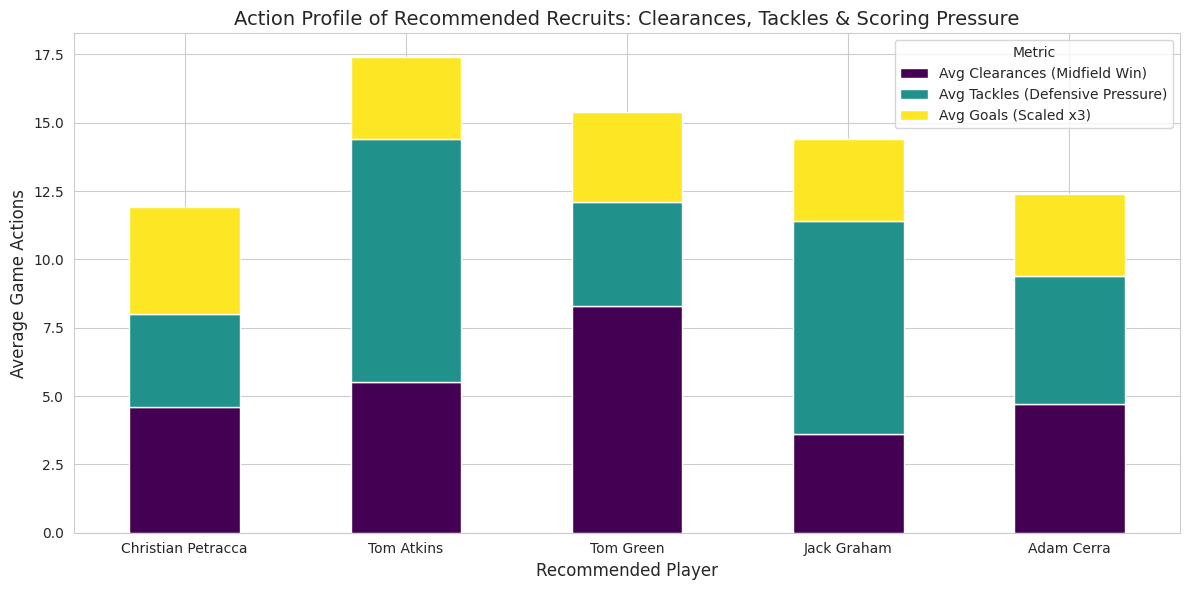

In [116]:
# 5. Visualization: Recruitment Value Breakdown (Stacked Bar Chart)
# We visualize WHY these players are recommended by showing their dual-threat capabilities.

plt.figure(figsize=(10, 6))

# Set the index to player names for plotting
rec_plot_data = final_recs[['player_name', 'avg_goals', 'avg_clearances', 'avg_tackles']].set_index('player_name')

# Multiply avg_goals by a constant for visual scaling on the same axis as tackles/clearances
rec_plot_data['avg_goals_scaled'] = rec_plot_data['avg_goals'] * 3

# Plot the stacked bar
rec_plot_data[['avg_clearances', 'avg_tackles', 'avg_goals_scaled']].plot(
    kind='bar',
    stacked=True,
    colormap='viridis',
    figsize=(12, 6)
)

plt.title("Action Profile of Recommended Recruits: Clearances, Tackles & Scoring Pressure", fontsize=14)
plt.xlabel("Recommended Player", fontsize=12)
plt.ylabel("Average Game Actions", fontsize=12)

# Custom legend to explain the scaled goals
plt.legend(['Avg Clearances (Midfield Win)', 'Avg Tackles (Defensive Pressure)', 'Avg Goals (Scaled x3)'], title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

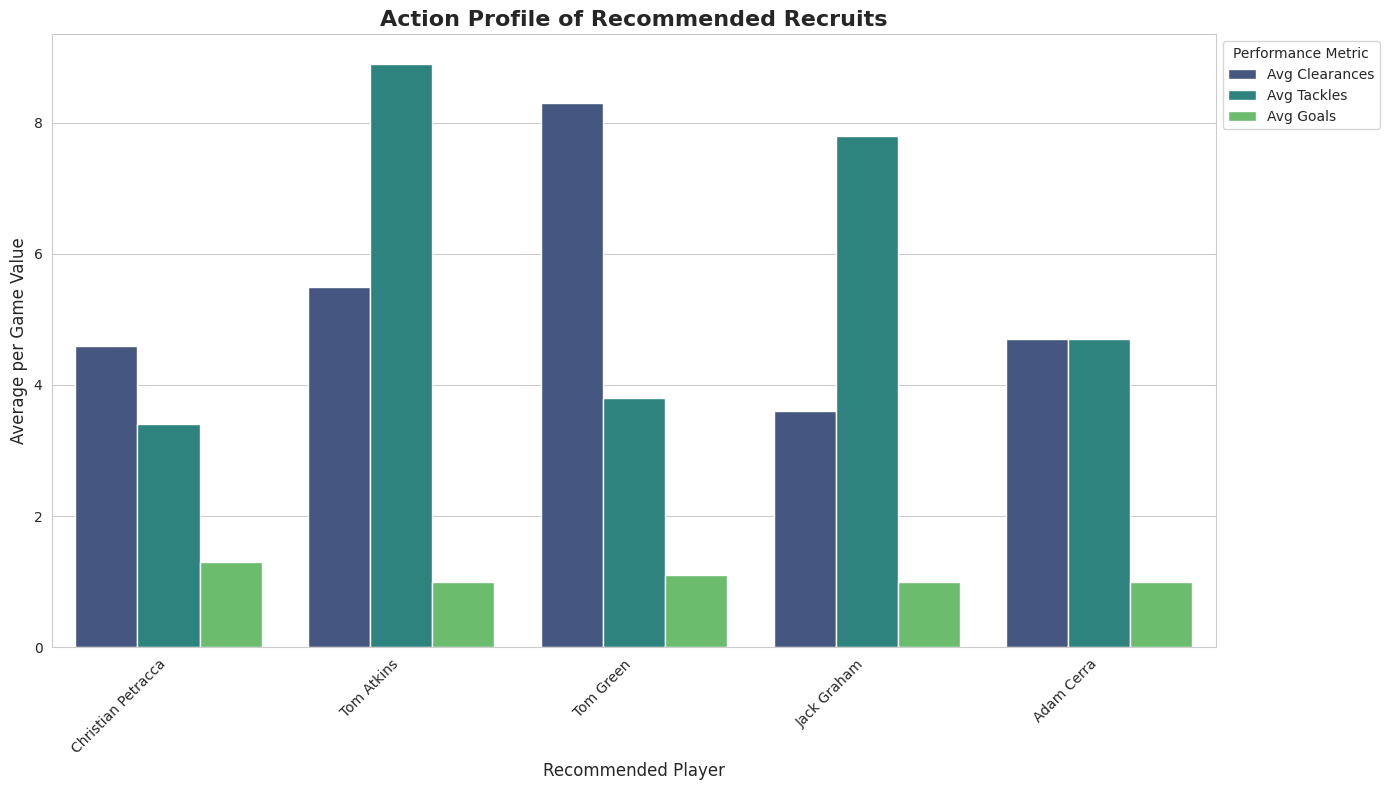

In [117]:
# 5. Visualization: Grouped Bar Chart for Key Metrics
# =======================================================
# Combine Clearances, Tackles, and Goals into a single grouped bar chart.

# Prepare the data by melting it to a long format suitable for grouped bar plots
rec_plot_data_melted = final_recs[['player_name', 'avg_clearances', 'avg_tackles', 'avg_goals']].melt(
    id_vars='player_name',
    value_vars=['avg_clearances', 'avg_tackles', 'avg_goals'],
    var_name='Metric',
    value_name='Value'
)

# Rename metrics for better readability in the legend
rec_plot_data_melted['Metric'] = rec_plot_data_melted['Metric'].map({
    'avg_clearances': 'Avg Clearances',
    'avg_tackles': 'Avg Tackles',
    'avg_goals': 'Avg Goals'
})

plt.figure(figsize=(14, 8))

# Create the grouped bar plot
sns.barplot(
    data=rec_plot_data_melted,
    x='player_name',
    y='Value',
    hue='Metric',
    palette='viridis' # Choose a color palette
)

plt.title("Action Profile of Recommended Recruits", fontsize=16, fontweight='bold')
plt.xlabel("Recommended Player", fontsize=12)
plt.ylabel("Average per Game Value", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate player names for better readability
plt.legend(title='Performance Metric', loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

#Explanation of every recommendation based on metrics and Visual Evidence
Rather than simply recommending the player with the highest absolute point total, the recruitment algorithm used a "Filter and Sort" methodology:

The PI Filter (Value Base): We first isolated the Top 50 players in the league using the custom Performance Index (PI). This ensures that any player we look at is mathematically proven to be elite.

The CV Sort (Risk Mitigation): Within that elite group of 50, we sorted the players by their Coefficient of Variation (CV) from lowest to highest.

The resulting 5 players (Tom Green, Tom Atkins, Adam Cerra, Jack Graham, and Christian Petracca) represent the pinnacle of risk-free investment.

Visual Evidence:
As shown in the Stacked Bar Chart, these recruits are not one-dimensional players. They possess a "dual-threat" capability:

They all average substantial tackles, proving they apply elite defensive pressure and win the ball back.

They log heavy clearances, proving they can dictate play from the center of the field.

They consistently contribute to the scoreboard (goals), meaning they provide end-to-end utility.

Recruiting players with a CV tightly clustered around 0.16 to 0.17 guarantees that the coaching staff will receive this exact, multi-faceted baseline output in 9 out of 10 matches they play.